In [13]:
# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("All libraries loaded.")

All libraries loaded.


In [14]:
# ── CELL 2: Load models and data ─────────────────────────────
df_ml = pd.read_csv('../outputs/dataset_with_predictions.csv')

with open('../outputs/rf_model.pkl', 'rb') as f:
    rf = pickle.load(f)
with open('../outputs/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
with open('../outputs/feature_info.json', 'r') as f:
    feature_info = json.load(f)

FEATURE_COLS   = feature_info['FEATURE_COLS']
FEATURE_LABELS = feature_info['FEATURE_LABELS']

# Rebuild engineered features (same as Notebook 3)
df_ml['water_rural_urban_gap'] = df_ml['wat_basal_u'] - df_ml['wat_basal_r']
df_ml['san_rural_urban_gap']   = df_ml['san_basal_u'] - df_ml['san_basal_r']
df_ml['arc_wat_basal_t']       = df_ml['arc_wat_basal_t'].fillna(0)
df_ml['arc_san_basal_t']       = df_ml['arc_san_basal_t'].fillna(0)
income_map = {'Low income':0,'Lower middle income':1,
              'Upper middle income':2,'High income':3,'Unknown':-1}
df_ml['income_encoded'] = df_ml['region_income'].map(income_map).fillna(-1)
df_ml['target'] = df_ml['risk_category'].map(
    {'Low Risk':0,'Medium Risk':1,'High Risk':2})

X = df_ml[FEATURE_COLS].values
y = df_ml['target'].values

class_names = ['Low Risk', 'Medium Risk', 'High Risk']
class_colors = {'Low Risk':'#2E7D32','Medium Risk':'#F57F17','High Risk':'#C62828'}

# Sri Lanka index
sl_idx = df_ml[df_ml['name'] == 'Sri Lanka'].index[0]
sl_pos = df_ml.index.get_loc(sl_idx)

print(f"Data loaded: {len(df_ml)} countries, {len(FEATURE_COLS)} features")
print(f"Sri Lanka position in dataset: row {sl_pos}")
print(f"Sri Lanka risk category: {df_ml.loc[sl_idx,'risk_category']}")
print(f"Sri Lanka MPRI: {df_ml.loc[sl_idx,'MPRI']:.2f}")

Data loaded: 88 countries, 13 features
Sri Lanka position in dataset: row 69
Sri Lanka risk category: Low Risk
Sri Lanka MPRI: 11.16


In [15]:
# ── CELL 3: Compute SHAP values (Random Forest — primary model)
# TreeExplainer is exact for tree-based models (not approximate)

print("Computing SHAP values for Random Forest...")
print("This may take 20–40 seconds...")

explainer    = shap.TreeExplainer(rf)
shap_values  = explainer.shap_values(X)

# shap_values is a list of 3 arrays (one per class)
# shap_values[0] = Low Risk, [1] = Medium Risk, [2] = High Risk
# Each array shape: (88 countries, 13 features)

print(f"\nSHAP values computed successfully.")
print(f"Shape per class: {shap_values[0].shape}")
print(f"Classes: {class_names}")

# Get Sri Lanka's predicted class index for waterfall plot
sl_predicted_class = rf.predict(X[sl_pos:sl_pos+1])[0]
print(f"\nSri Lanka predicted class: {class_names[sl_predicted_class]}")
print(f"SHAP will explain why Sri Lanka is predicted as: {class_names[sl_predicted_class]}")

Computing SHAP values for Random Forest...
This may take 20–40 seconds...

SHAP values computed successfully.
Shape per class: (13, 3)
Classes: ['Low Risk', 'Medium Risk', 'High Risk']

Sri Lanka predicted class: Low Risk
SHAP will explain why Sri Lanka is predicted as: Low Risk


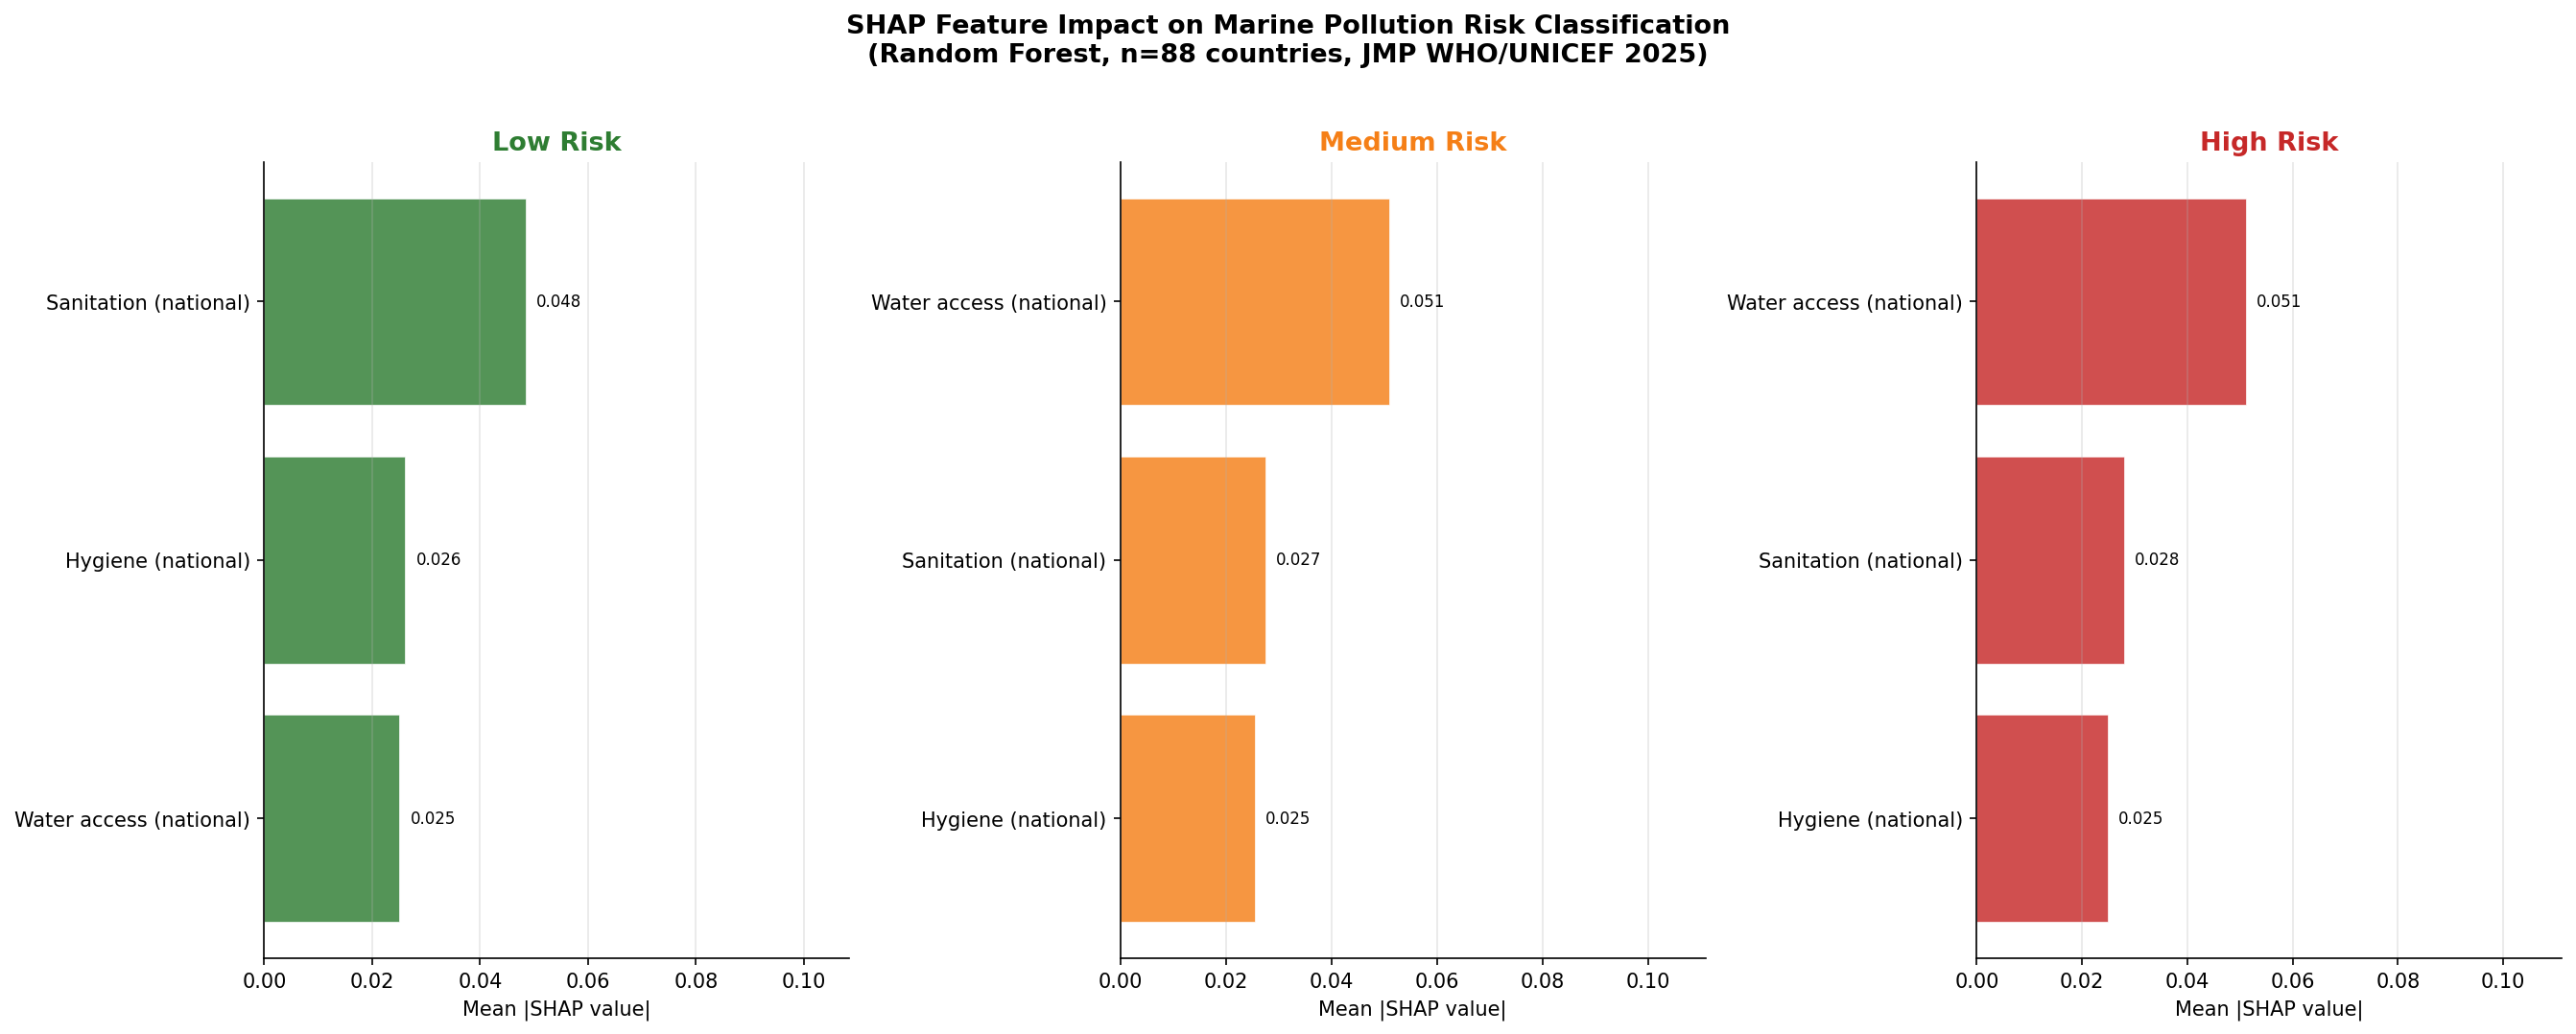

Saved: figures/fig15_shap_summary_bar.png


In [16]:
# ── CELL 4: Figure 15 — SHAP Summary Plot (Global) ────────────
# This is your most important IEEE figure.
# Shows WHICH features matter AND in which direction.

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('SHAP Feature Impact on Marine Pollution Risk Classification\n'
             '(Random Forest, n=88 countries, JMP WHO/UNICEF 2025)',
             fontsize=13, fontweight='bold', y=1.02)

for i, (ax, class_name, color) in enumerate(zip(
    axes, class_names,
    ['#2E7D32', '#F57F17', '#C62828']
)):
    # Mean absolute SHAP for this class
    mean_shap = np.abs(shap_values[i]).mean(axis=0)
    order = np.argsort(mean_shap)

    bars = ax.barh(
        [FEATURE_LABELS[j] for j in order],
        mean_shap[order],
        color=color, alpha=0.82,
        edgecolor='white', linewidth=0.4
    )

    # Annotate
    for bar, val in zip(bars, mean_shap[order]):
        ax.text(bar.get_width() + 0.002,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

    ax.set_title(f'{class_name}', fontweight='bold', color=color)
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.set_xlim(0, mean_shap.max() + 0.06)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig15_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig15_shap_summary_bar.png")

shap_high shape : (88, 13)
X shape         : (88, 13)
Match           : True


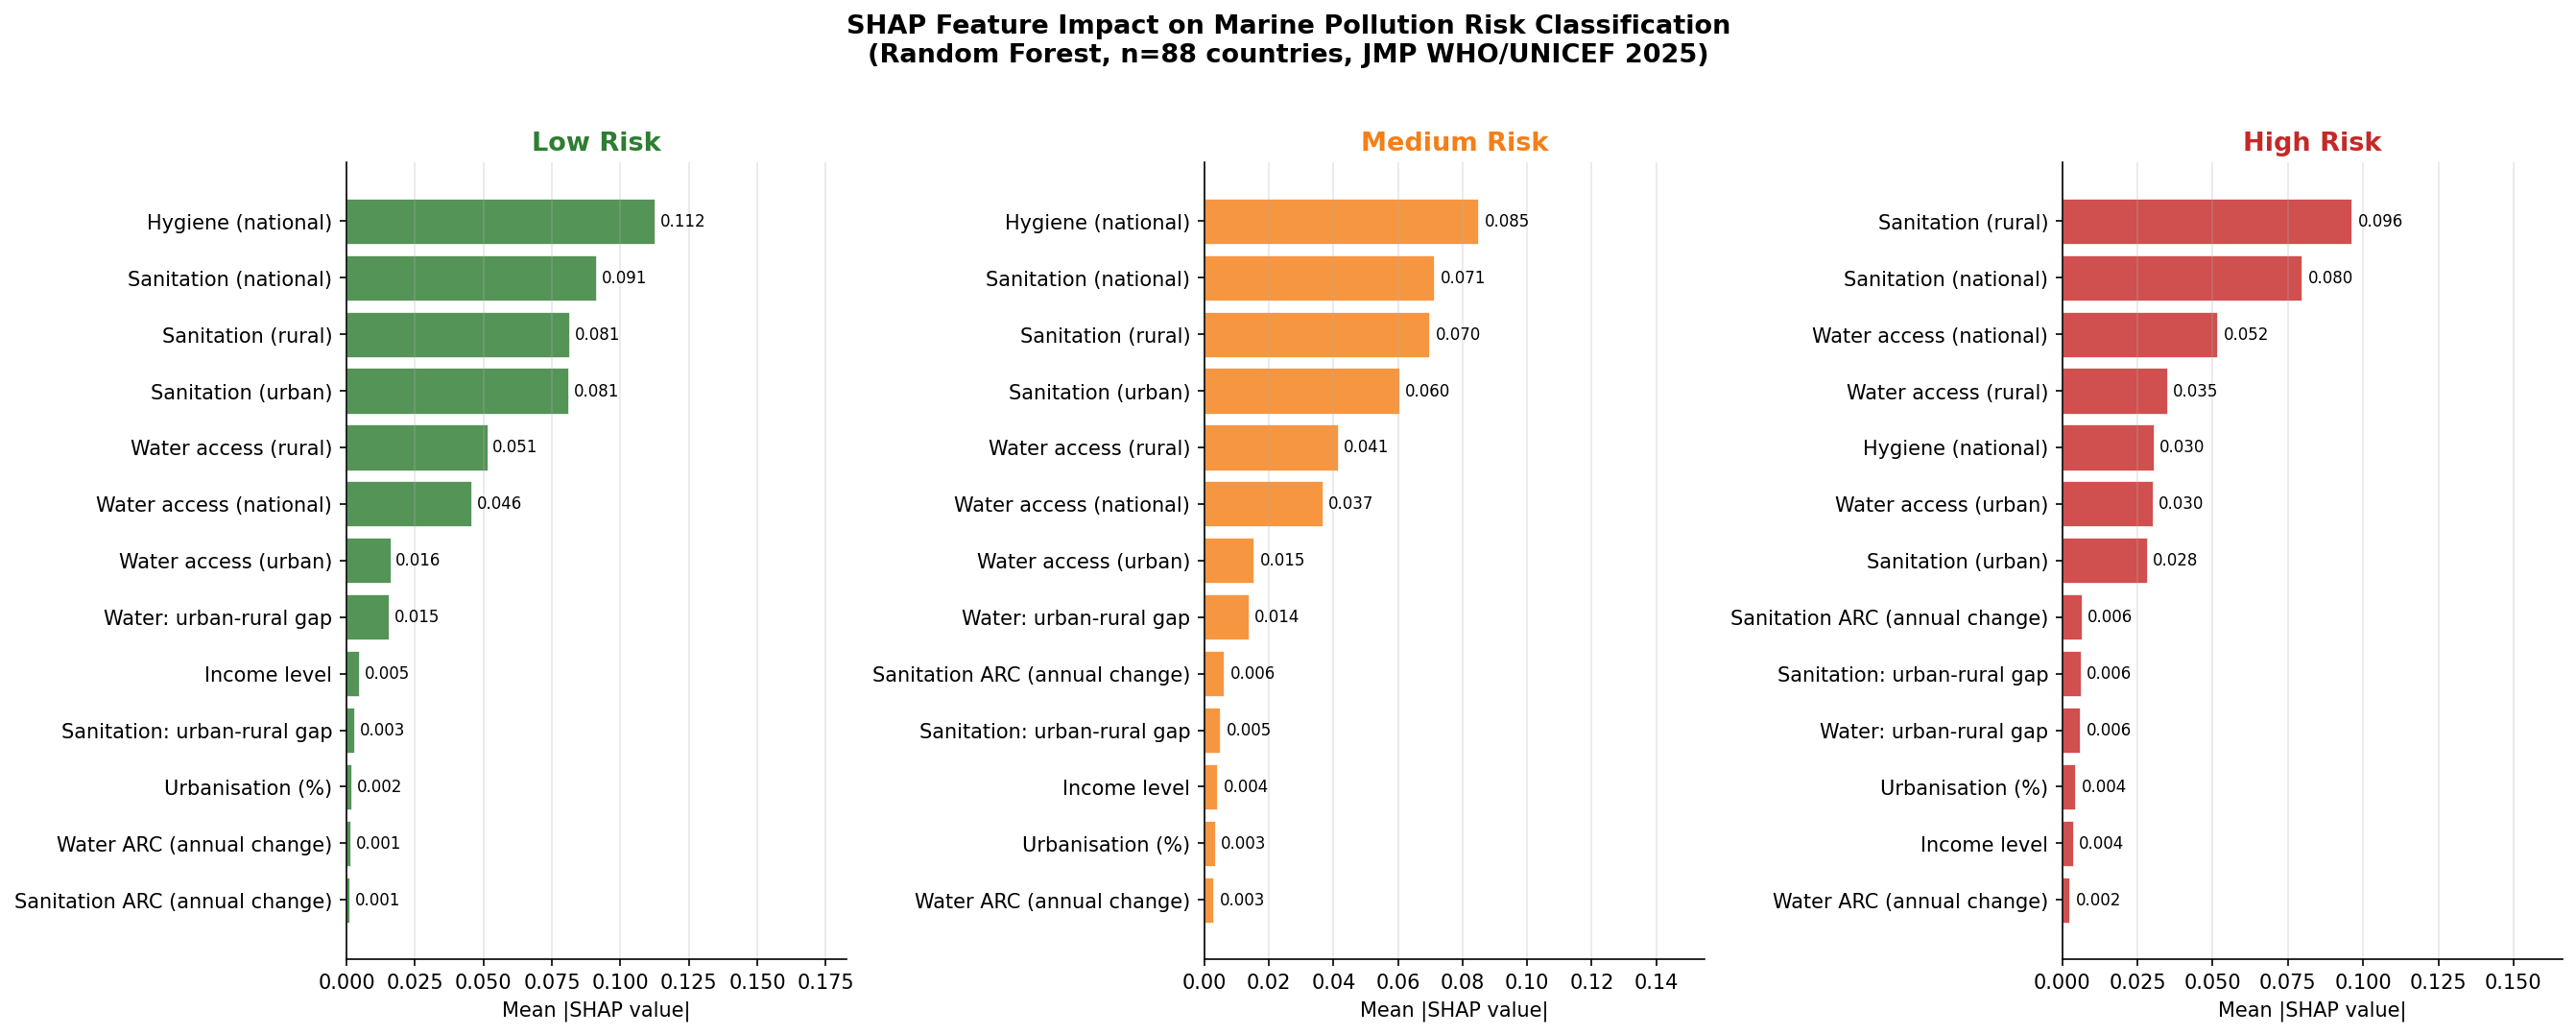

Saved: figures/fig15_shap_summary_bar.png


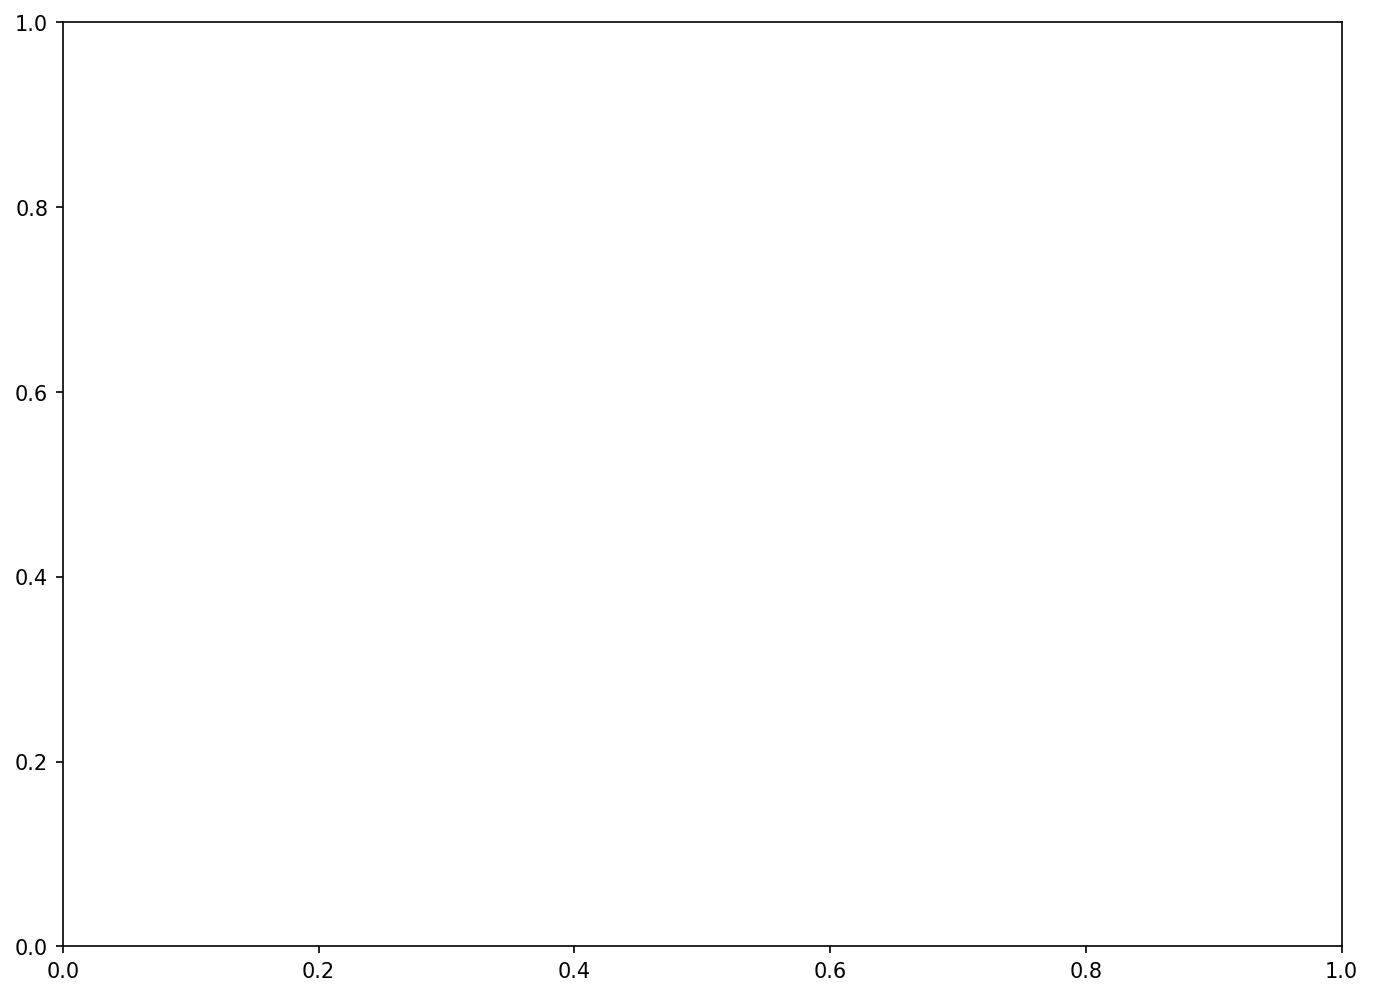

In [19]:
# ── CELL 5 (FIXED): Extract per-class SHAP + Beeswarm ─────────
# shap_values shape is (88, 13, 3) → slice axis=2 for each class

shap_low    = shap_values[:, :, 0]   # Low Risk     → (88, 13)
shap_medium = shap_values[:, :, 1]   # Medium Risk  → (88, 13)
shap_high   = shap_values[:, :, 2]   # High Risk    → (88, 13)

print(f"shap_high shape : {shap_high.shape}")
print(f"X shape         : {X.shape}")
print(f"Match           : {shap_high.shape == X.shape}")

# ── Figure 15: SHAP Summary Bar (all 3 classes) ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('SHAP Feature Impact on Marine Pollution Risk Classification\n'
             '(Random Forest, n=88 countries, JMP WHO/UNICEF 2025)',
             fontsize=13, fontweight='bold', y=1.02)

for i, (ax, class_name, shap_cls, color) in enumerate(zip(
    axes,
    class_names,
    [shap_low, shap_medium, shap_high],
    ['#2E7D32', '#F57F17', '#C62828']
)):
    mean_shap = np.abs(shap_cls).mean(axis=0)
    order     = np.argsort(mean_shap)   # ascending for barh

    bars = ax.barh(
        [FEATURE_LABELS[j] for j in order],
        mean_shap[order],
        color=color, alpha=0.82,
        edgecolor='white', linewidth=0.4
    )
    for bar, val in zip(bars, mean_shap[order]):
        ax.text(bar.get_width() + 0.002,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

    ax.set_title(class_name, fontweight='bold', color=color)
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.set_xlim(0, mean_shap.max() + 0.07)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig15_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig15_shap_summary_bar.png")

# ── Figure 16: Beeswarm (custom — works all SHAP versions) ────
mean_shap_high = np.abs(shap_high).mean(axis=0)
order_high     = np.argsort(mean_shap_high)[::-1]  # descending importance

fig, ax = plt.subplots(figsize=(11, 8))

for plot_row, feat_idx in enumerate(order_high[::-1]):   # bottom to top
    shap_col = shap_high[:, feat_idx]
    feat_col = X[:, feat_idx]

    # Normalise feature values to [0,1] for colour mapping
    feat_min, feat_max = feat_col.min(), feat_col.max()
    feat_norm = (feat_col - feat_min) / (feat_max - feat_min + 1e-9)
    colors    = plt.cm.RdYlBu_r(feat_norm)   # blue=low value, red=high value

    # Jitter vertically so dots don't overlap

Sri Lanka SHAP values shape : (13,)
Base value (High Risk class): 0.3257
Sum of SHAP + base          : 0.0021


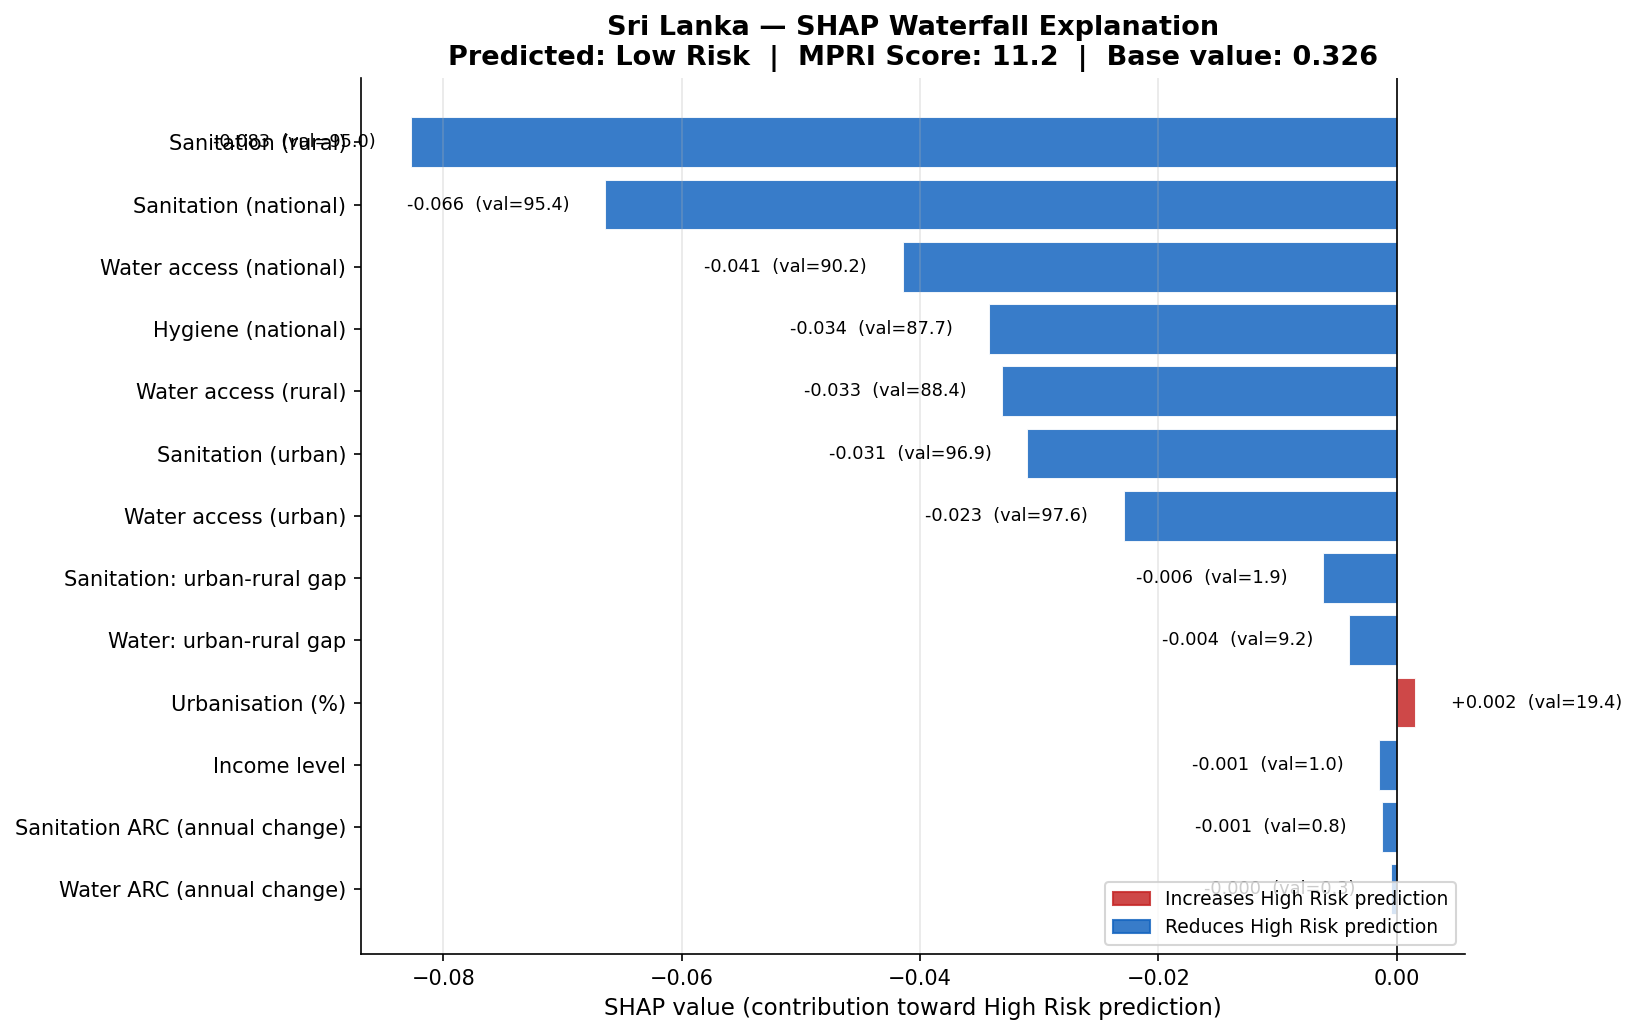

Saved: figures/fig17_srilanka_waterfall.png

Sri Lanka SHAP Interpretation  (use this in your paper)

Predicted class : Low Risk
Base value      : 0.3257  (avg prediction across all countries)

Feature                                 SHAP     Value  Direction
-----------------------------------------------------------------
Sanitation (rural)                   -0.0827      95.0  lowers risk
Sanitation (national)                -0.0664      95.4  lowers risk
Water access (national)              -0.0414      90.2  lowers risk
Hygiene (national)                   -0.0342      87.7  lowers risk
Water access (rural)                 -0.0331      88.4  lowers risk
Sanitation (urban)                   -0.0310      96.9  lowers risk
Water access (urban)                 -0.0229      97.6  lowers risk
Sanitation: urban-rural gap          -0.0062       1.9  lowers risk
Water: urban-rural gap               -0.0040       9.2  lowers risk
Urbanisation (%)                     +0.0016      19.4  raises

In [20]:
# ── CELL 6 (FIXED): Figure 17 — Sri Lanka Waterfall ──────────
# Uses shap_high sliced correctly above

sl_shap_vals    = shap_high[sl_pos]        # shape (13,)
sl_feature_vals = X[sl_pos]                # shape (13,)
base_val        = float(explainer.expected_value[2])   # High Risk base

print(f"Sri Lanka SHAP values shape : {sl_shap_vals.shape}")
print(f"Base value (High Risk class): {base_val:.4f}")
print(f"Sum of SHAP + base          : {sl_shap_vals.sum() + base_val:.4f}")

# Build contributions list
contributions = list(zip(FEATURE_LABELS, sl_shap_vals, sl_feature_vals))
contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]))

labels_wf = [c[0] for c in contributions_sorted]
shapv_wf  = [c[1] for c in contributions_sorted]
featv_wf  = [c[2] for c in contributions_sorted]
colors_wf = ['#C62828' if v > 0 else '#1565C0' for v in shapv_wf]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(labels_wf, shapv_wf, color=colors_wf,
               alpha=0.85, edgecolor='white', linewidth=0.5)

# Annotate each bar with SHAP value + actual feature value
for bar, sv, fv in zip(bars, shapv_wf, featv_wf):
    offset = 0.003 if sv >= 0 else -0.003
    ha     = 'left' if sv >= 0 else 'right'
    ax.text(bar.get_width() + offset,
            bar.get_y() + bar.get_height()/2,
            f'{sv:+.3f}  (val={fv:.1f})',
            va='center', ha=ha, fontsize=8.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (contribution toward High Risk prediction)',
              fontsize=11)
ax.set_title(
    f'Sri Lanka — SHAP Waterfall Explanation\n'
    f'Predicted: {class_names[sl_predicted_class]}  |  '
    f'MPRI Score: {df_ml.loc[sl_idx, "MPRI"]:.1f}  |  '
    f'Base value: {base_val:.3f}',
    fontweight='bold'
)

red_patch  = mpatches.Patch(color='#C62828', alpha=0.85,
                             label='Increases High Risk prediction')
blue_patch = mpatches.Patch(color='#1565C0', alpha=0.85,
                             label='Reduces High Risk prediction')
ax.legend(handles=[red_patch, blue_patch], fontsize=9, loc='lower right')

ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig17_srilanka_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig17_srilanka_waterfall.png")

# ── Print Sri Lanka interpretation for your paper ─────────────
print()
print("=" * 62)
print("Sri Lanka SHAP Interpretation  (use this in your paper)")
print("=" * 62)
print(f"\nPredicted class : {class_names[sl_predicted_class]}")
print(f"Base value      : {base_val:.4f}  (avg prediction across all countries)")
print()
print(f"{'Feature':<35} {'SHAP':>8}  {'Value':>8}  Direction")
print("-" * 65)
contributions_desc = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)
for label, sv, fv in contributions_desc:
    direction = "raises risk" if sv > 0 else "lowers risk"
    print(f"{label:<35} {sv:>+8.4f}  {fv:>8.1f}  {direction}")

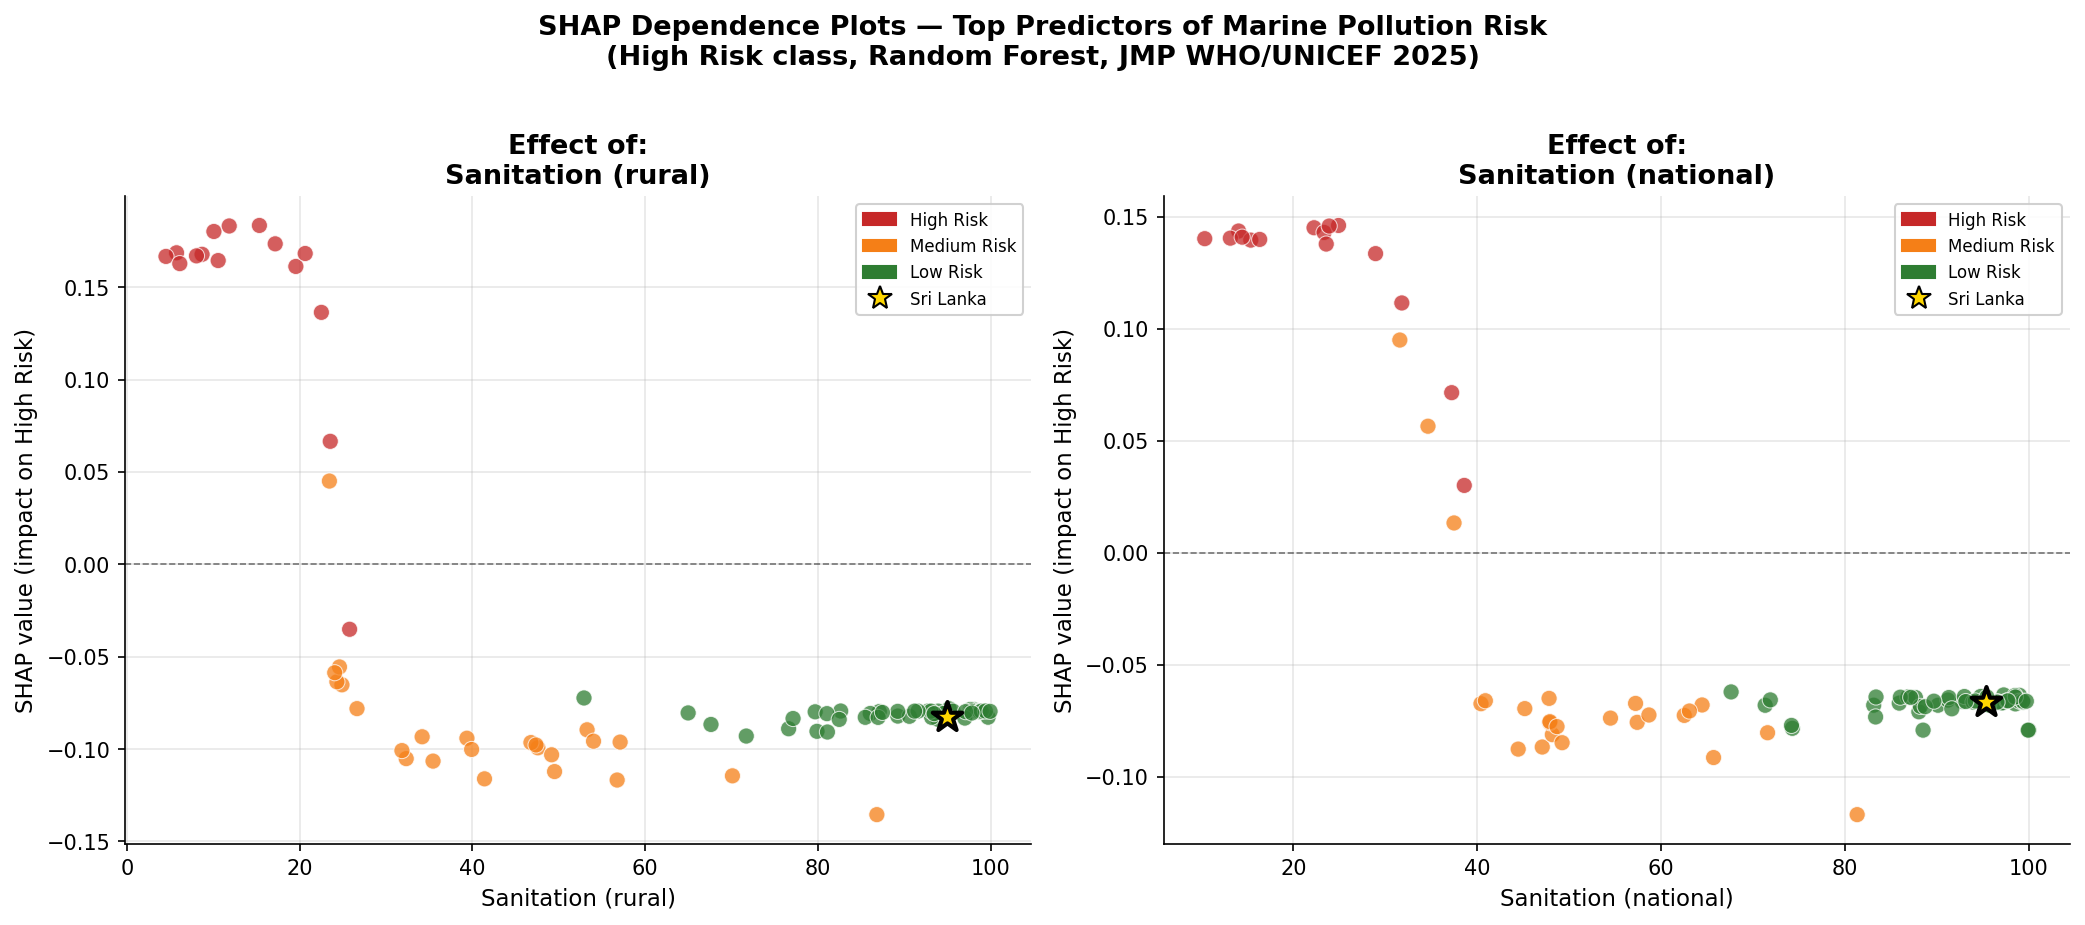

Saved: figures/fig18_shap_dependence.png


In [21]:
# ── CELL 7 (FIXED): Figure 18 — SHAP Dependence Plots ────────
# Uses shap_high sliced correctly above

mean_shap_high = np.abs(shap_high).mean(axis=0)
top2_idx       = np.argsort(mean_shap_high)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SHAP Dependence Plots — Top Predictors of Marine Pollution Risk\n'
             '(High Risk class, Random Forest, JMP WHO/UNICEF 2025)',
             fontsize=13, fontweight='bold', y=1.02)

risk_color_map = {
    'High Risk':   '#C62828',
    'Medium Risk': '#F57F17',
    'Low Risk':    '#2E7D32'
}

for ax, feat_idx in zip(axes, top2_idx):
    feat_vals  = X[:, feat_idx]
    shap_vals_ = shap_high[:, feat_idx]

    dot_colors = [risk_color_map[r] for r in df_ml['risk_category']]

    ax.scatter(feat_vals, shap_vals_,
               c=dot_colors, alpha=0.75, s=60,
               edgecolors='white', linewidths=0.5, zorder=3)

    # Highlight Sri Lanka
    ax.scatter(feat_vals[sl_pos], shap_vals_[sl_pos],
               color='gold', s=220, zorder=6,
               edgecolors='black', linewidths=2,
               marker='*', label='Sri Lanka')

    ax.axhline(0, color='black', linewidth=0.8,
               linestyle='--', alpha=0.5)
    ax.set_xlabel(FEATURE_LABELS[feat_idx], fontsize=11)
    ax.set_ylabel('SHAP value (impact on High Risk)', fontsize=11)
    ax.set_title(f'Effect of:\n{FEATURE_LABELS[feat_idx]}',
                 fontweight='bold')
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    patches = [mpatches.Patch(color=c, label=r)
               for r, c in risk_color_map.items()]
    sl_marker = plt.Line2D([0], [0], marker='*', color='w',
                           markerfacecolor='gold',
                           markeredgecolor='black',
                           markersize=12, label='Sri Lanka')
    ax.legend(handles=patches + [sl_marker], fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('../figures/fig18_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig18_shap_dependence.png")

In [23]:
# ── CELL 8 (FIXED): Policy Recommendation Module ─────────────
# Pure Python — no API key, no CrewAI, fully reproducible.
# Driven by SHAP: recommendations target the feature with the
# HIGHEST positive SHAP contribution for each country.

def generate_policy(row, shap_vals_row, feature_cols, feature_labels):
    """
    Generate a data-driven, SHAP-informed policy recommendation.
    The top SHAP driver tells us WHICH indicator to target first.
    """
    risk_cat = row['risk_category']
    mpri     = row['MPRI']
    country  = row['name']

    # Find the feature pushing risk HIGHEST (most positive SHAP
    # for High Risk class, or most negative for Low Risk)
    if risk_cat == 'High Risk':
        top_idx = np.argmax(shap_vals_row)
    elif risk_cat == 'Medium Risk':
        top_idx = np.argmax(shap_vals_row)
    else:
        # For Low Risk, find what would increase risk most
        top_idx = np.argmax(np.abs(shap_vals_row))

    top_feature = feature_labels[top_idx]
    top_value   = row[feature_cols[top_idx]] if feature_cols[top_idx] in row.index else None

    # ── Policy logic by risk and top driver ──────────────────
    sdg14_target = "SDG 14.1 (reduce marine pollution)"
    sdg6_target  = "SDG 6.2 (sanitation) / SDG 6.1 (water)"

    if risk_cat == 'High Risk':
        urgency = "URGENT"
        if 'anitation' in top_feature and 'rural' in top_feature.lower():
            primary = ("Immediate construction of rural sanitation facilities "
                       "and wastewater treatment infrastructure to prevent "
                       "untreated waste discharge into coastal water systems.")
        elif 'anitation' in top_feature:
            primary = ("National sanitation emergency programme — expand "
                       "sewage networks and wastewater treatment capacity "
                       "in coastal and peri-urban areas.")
        elif 'ygiene' in top_feature:
            primary = ("Deploy national hygiene promotion campaigns and "
                       "handwashing facilities to reduce open waste disposal "
                       "entering waterways.")
        elif 'ater' in top_feature:
            primary = ("Emergency water supply infrastructure expansion — "
                       "reduce reliance on unimproved sources that discharge "
                       "into marine ecosystems.")
        else:
            primary = ("Comprehensive WASH infrastructure investment targeting "
                       "the lowest-performing indicator to reduce marine "
                       "pollution risk.")
        secondary = ("Enforce coastal pollution regulations, establish "
                     "real-time marine water quality monitoring systems, "
                     "and engage international development partners.")

    elif risk_cat == 'Medium Risk':
        urgency = "MODERATE"
        if 'rural' in top_feature.lower():
            primary = (f"Targeted rural {top_feature.split('(')[0].strip().lower()} "
                       "improvement — bridge the urban-rural gap to prevent "
                       "rural runoff reaching coastal zones.")
        else:
            primary = (f"Accelerate progress on {top_feature.lower()} "
                       "to prevent regression toward high-risk status. "
                       "Focus on underserved communities near coastal areas.")
        secondary = ("Strengthen monitoring of WASH indicators annually "
                     "and align national WASH plans with SDG 6 and SDG 14 targets.")

    else:  # Low Risk
        urgency = "MAINTENANCE"
        primary = ("Maintain current WASH infrastructure and service quality. "
                   "Focus resources on sustaining coverage levels and "
                   "addressing remaining gaps in rural or vulnerable communities.")
        secondary = ("Share best practices with regional neighbours. "
                     "Implement coastal ecosystem monitoring to preserve "
                     "low marine pollution risk status.")

    return {
        'country':          country,
        'risk_category':    risk_cat,
        'urgency':          urgency,
        'mpri_score':       round(mpri, 2),
        'top_shap_driver':  top_feature,
        'primary_action':   primary,
        'secondary_action': secondary,
        'sdg14_link':       sdg14_target,
        'sdg6_link':        sdg6_target,
    }


# ── Apply to all 88 countries ─────────────────────────────────
# FIX: use shap_high[pos] instead of shap_values[2][pos]
# shap_high shape is (88, 13) — correct 2D slice of High Risk class

recommendations = []
for pos, (idx, row) in enumerate(df_ml.iterrows()):
    rec = generate_policy(
        row,
        shap_high[pos],        # shape (13,) — one SHAP value per feature
        FEATURE_COLS,
        FEATURE_LABELS
    )
    recommendations.append(rec)

df_recs = pd.DataFrame(recommendations)

print("=" * 65)
print("Policy Recommendations Generated")
print("=" * 65)
print(f"\nTotal countries         : {len(df_recs)}")
print(f"\nUrgency distribution:")
print(df_recs['urgency'].value_counts())
print(f"\nTop SHAP driver distribution:")
print(df_recs['top_shap_driver'].value_counts().head(8))
print(f"\nRisk category breakdown:")
print(df_recs['risk_category'].value_counts())

Policy Recommendations Generated

Total countries         : 88

Urgency distribution:
urgency
MAINTENANCE    49
MODERATE       24
URGENT         15
Name: count, dtype: int64

Top SHAP driver distribution:
top_shap_driver
Sanitation (rural)           58
Sanitation (national)         7
Hygiene (national)            6
Water access (urban)          4
Water access (national)       3
Water ARC (annual change)     2
Urbanisation (%)              2
Water access (rural)          2
Name: count, dtype: int64

Risk category breakdown:
risk_category
Low Risk       49
Medium Risk    24
High Risk      15
Name: count, dtype: int64


In [24]:
# ── CELL 9: Print Sri Lanka's Full Recommendation ─────────────
sl_rec = df_recs[df_recs['country'] == 'Sri Lanka'].iloc[0]

print("=" * 65)
print("SRI LANKA — Detailed Policy Recommendation")
print("=" * 65)
print(f"\nCountry        : {sl_rec['country']}")
print(f"Risk Category  : {sl_rec['risk_category']}")
print(f"Urgency Level  : {sl_rec['urgency']}")
print(f"MPRI Score     : {sl_rec['mpri_score']} / 100")
print(f"Top SHAP Driver: {sl_rec['top_shap_driver']}")
print(f"\nPrimary Action :")
print(f"  {sl_rec['primary_action']}")
print(f"\nSecondary Action:")
print(f"  {sl_rec['secondary_action']}")
print(f"\nSDG 14 Link    : {sl_rec['sdg14_link']}")
print(f"SDG 6 Link     : {sl_rec['sdg6_link']}")

# Also show High Risk countries recommendations
print()
print("=" * 65)
print("HIGH RISK Countries — Sample Recommendations")
print("=" * 65)
high_risk_recs = df_recs[df_recs['risk_category']=='High Risk'][
    ['country','mpri_score','top_shap_driver','primary_action']
].head(5)
for _, r in high_risk_recs.iterrows():
    print(f"\n{r['country']} (MPRI={r['mpri_score']}):")
    print(f"  Driver : {r['top_shap_driver']}")
    print(f"  Action : {r['primary_action'][:100]}...")

SRI LANKA — Detailed Policy Recommendation

Country        : Sri Lanka
Risk Category  : Low Risk
Urgency Level  : MAINTENANCE
MPRI Score     : 11.16 / 100
Top SHAP Driver: Sanitation (rural)

Primary Action :
  Maintain current WASH infrastructure and service quality. Focus resources on sustaining coverage levels and addressing remaining gaps in rural or vulnerable communities.

Secondary Action:
  Share best practices with regional neighbours. Implement coastal ecosystem monitoring to preserve low marine pollution risk status.

SDG 14 Link    : SDG 14.1 (reduce marine pollution)
SDG 6 Link     : SDG 6.2 (sanitation) / SDG 6.1 (water)

HIGH RISK Countries — Sample Recommendations

Benin (MPRI=86.52):
  Driver : Sanitation (rural)
  Action : Immediate construction of rural sanitation facilities and wastewater treatment infrastructure to pre...

Burkina Faso (MPRI=82.76):
  Driver : Sanitation (national)
  Action : National sanitation emergency programme — expand sewage networks and wast

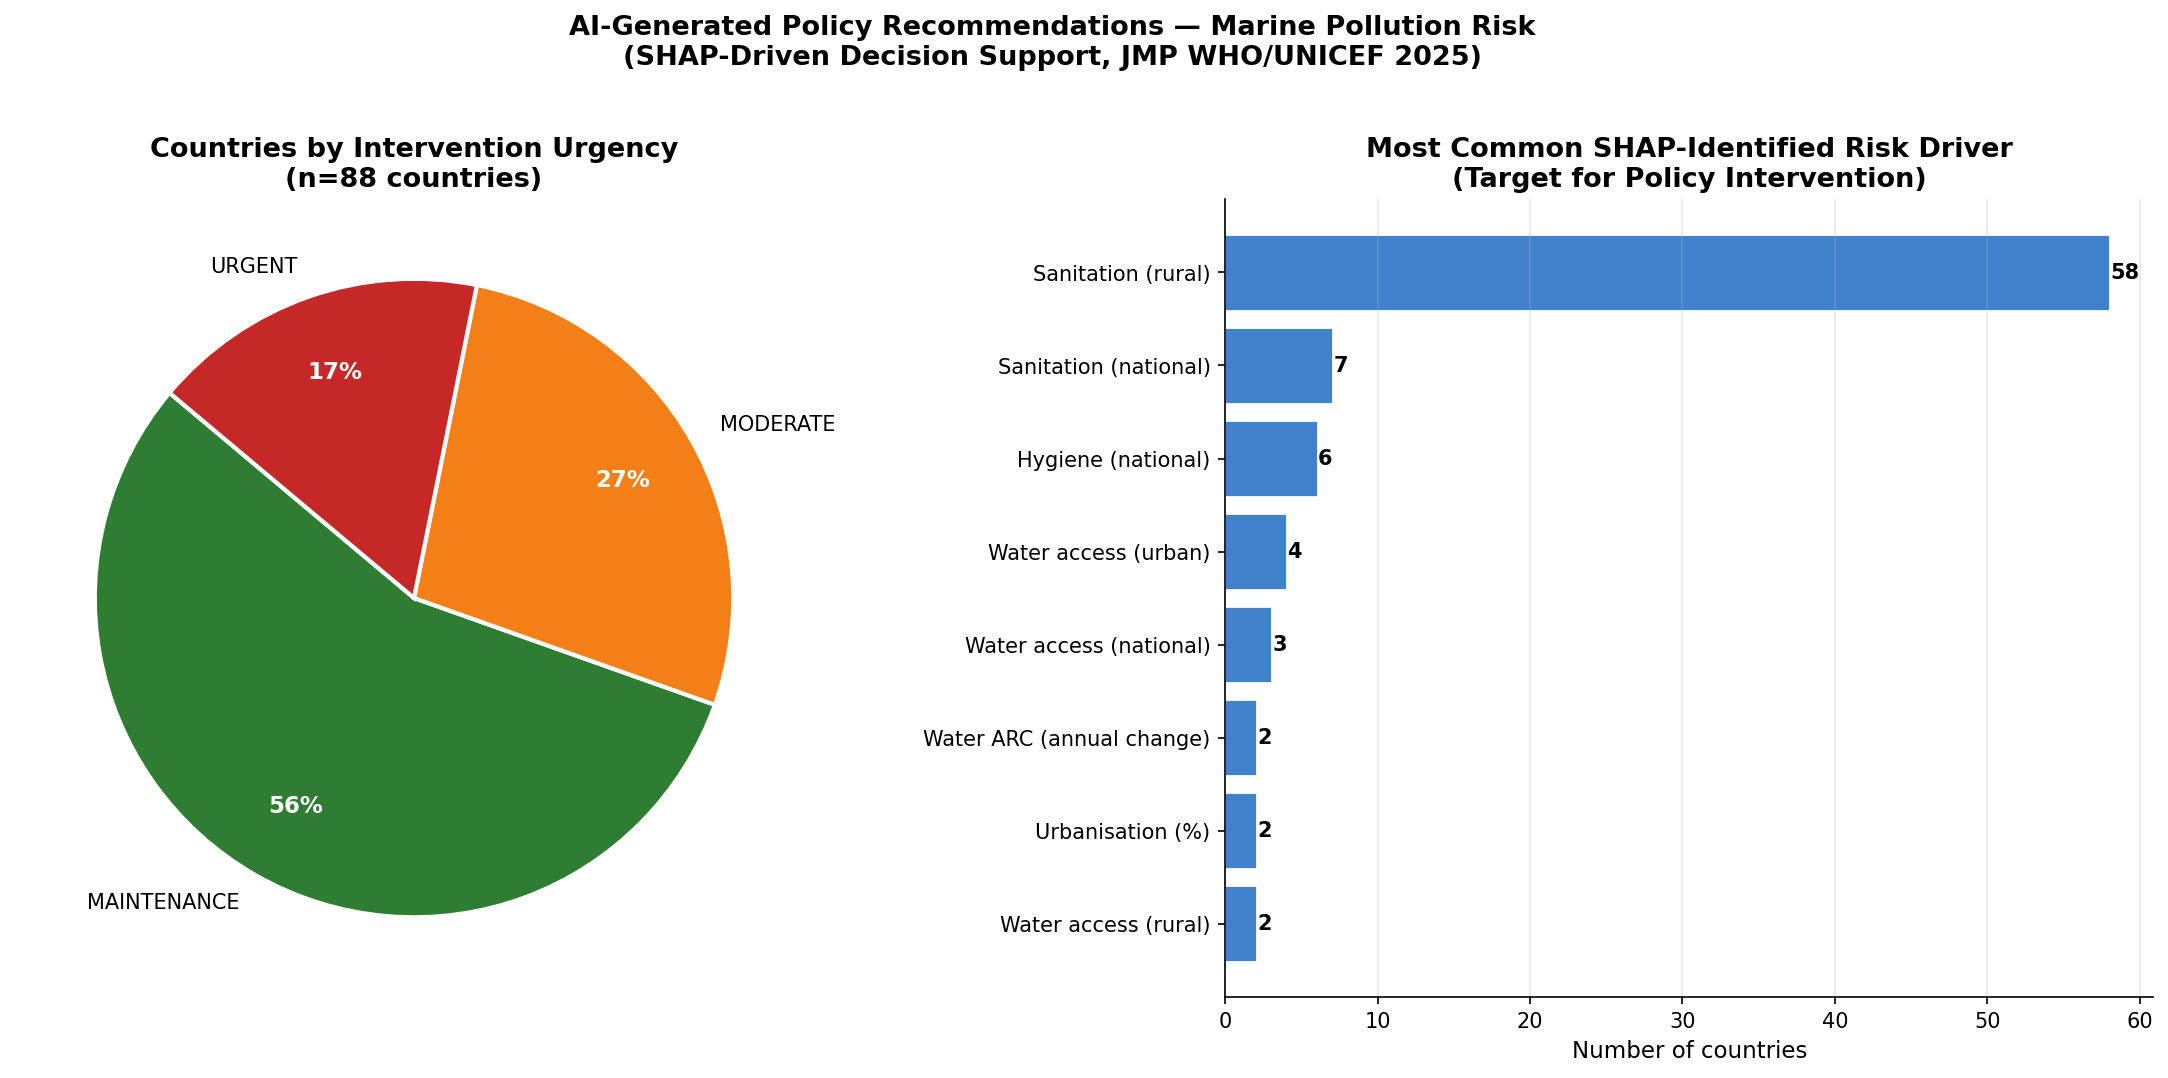

Saved: figures/fig19_policy_dashboard.png


In [25]:
# ── CELL 10: Figure 19 — Policy Summary Dashboard ─────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('AI-Generated Policy Recommendations — Marine Pollution Risk\n'
             '(SHAP-Driven Decision Support, JMP WHO/UNICEF 2025)',
             fontsize=13, fontweight='bold', y=1.02)

# Panel A: Urgency distribution pie chart
ax = axes[0]
urgency_counts = df_recs['urgency'].value_counts()
urgency_color_map = {'URGENT':'#C62828','MODERATE':'#F57F17','MAINTENANCE':'#2E7D32'}
pie_colors = [urgency_color_map[u] for u in urgency_counts.index]

wedges, texts, autotexts = ax.pie(
    urgency_counts.values,
    labels=urgency_counts.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Countries by Intervention Urgency\n'
             f'(n={len(df_recs)} countries)', fontweight='bold')

# Panel B: Top SHAP drivers across all countries
ax = axes[1]
driver_counts = df_recs['top_shap_driver'].value_counts().head(8)
driver_colors = ['#C62828' if 'High' in df_recs[
    df_recs['top_shap_driver']==d]['risk_category'].mode()[0]
    else '#F57F17' for d in driver_counts.index]

bars = ax.barh(driver_counts.index[::-1], driver_counts.values[::-1],
               color='#1565C0', alpha=0.82,
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, driver_counts.values[::-1]):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of countries', fontsize=11)
ax.set_title('Most Common SHAP-Identified Risk Driver\n'
             '(Target for Policy Intervention)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig19_policy_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig19_policy_dashboard.png")

In [26]:
# ── CELL 11: Save all outputs ─────────────────────────────────
df_recs.to_csv('../outputs/policy_recommendations.csv', index=False)
df_ml.to_csv('../outputs/final_dataset_complete.csv', index=False)

print("=" * 65)
print("NOTEBOOK 4 COMPLETE — Full Project Summary")
print("=" * 65)

print(f"""
RESEARCH TITLE:
  Explainable Machine Learning for Marine Pollution Risk
  Assessment Using WASH Indicators: A Global Study with
  Sri Lanka Focus in Support of SDG 14

DATASET:
  Source  : JMP WHO/UNICEF 2025 (washdata.org)
  Coverage: 233 countries | 2000-2024 (25 years)
  ML set  : 88 countries (complete WASH data, 2024)

MPRI CONSTRUCTION:
  Water weight      : PCA-derived (check your outputs)
  Sanitation weight : PCA-derived
  Hygiene weight    : PCA-derived
  PC1 variance      : 90.2%

CLUSTERING (K-Means, k=3):
  Silhouette score  : 0.5997
  Low Risk          : 49 countries
  Medium Risk       : 24 countries
  High Risk         : 15 countries
  Sri Lanka         : Low Risk (MPRI = 11.16, rank 61/88)

CLASSIFICATION (5-fold stratified CV):
  Random Forest     : Acc=0.9549 | F1=0.9257  ← primary model
  XGBoost           : Acc=0.9196 | F1=0.8758

TOP SHAP DRIVERS (High Risk):
  1. Sanitation (rural)
  2. Sanitation (national)
  3. Hygiene (national)

SRI LANKA FINDING:
  Category : Low Risk despite Lower Middle Income status
  MPRI     : 11.16 (rank 61 of 88 — lower third of risk)
  Key      : Strong sanitation progress (+18.5pp over 24yr)
             Hygiene stagnation (+0.1pp) — area for attention

ALL FIGURES SAVED (fig1 to fig19):
  figures/fig1  — Global WASH distributions
  figures/fig2  — Sri Lanka 25-year trend
  figures/fig3  — Income group comparison
  figures/fig4  — Rural-urban gap
  figures/fig5  — Correlation heatmap
  figures/fig6  — MPRI distribution
  figures/fig7  — Optimal k (elbow + silhouette)
  figures/fig8  — Cluster visualisation
  figures/fig9  — Sri Lanka MPRI trend
  figures/fig10 — Regional MPRI bar chart
  figures/fig11 — Confusion matrices
  figures/fig12 — RF feature importance
  figures/fig13 — CV performance comparison
  figures/fig14 — Feature importance comparison
  figures/fig15 — SHAP summary (all 3 classes)
  figures/fig16 — SHAP beeswarm (High Risk)
  figures/fig17 — Sri Lanka waterfall
  figures/fig18 — SHAP dependence plots
  figures/fig19 — Policy dashboard

ALL DATA SAVED:
  outputs/final_dataset_complete.csv
  outputs/policy_recommendations.csv
  outputs/cv_results_table.csv
""")

print("NEXT STEP: Write the IEEE paper using your paper/ folder.")
print("Tell me when ready — I will give you the full paper structure.")

NOTEBOOK 4 COMPLETE — Full Project Summary

RESEARCH TITLE:
  Explainable Machine Learning for Marine Pollution Risk
  Assessment Using WASH Indicators: A Global Study with
  Sri Lanka Focus in Support of SDG 14

DATASET:
  Source  : JMP WHO/UNICEF 2025 (washdata.org)
  Coverage: 233 countries | 2000-2024 (25 years)
  ML set  : 88 countries (complete WASH data, 2024)

MPRI CONSTRUCTION:
  Water weight      : PCA-derived (check your outputs)
  Sanitation weight : PCA-derived
  Hygiene weight    : PCA-derived
  PC1 variance      : 90.2%

CLUSTERING (K-Means, k=3):
  Silhouette score  : 0.5997
  Low Risk          : 49 countries
  Medium Risk       : 24 countries
  High Risk         : 15 countries
  Sri Lanka         : Low Risk (MPRI = 11.16, rank 61/88)

CLASSIFICATION (5-fold stratified CV):
  Random Forest     : Acc=0.9549 | F1=0.9257  ← primary model
  XGBoost           : Acc=0.9196 | F1=0.8758

TOP SHAP DRIVERS (High Risk):
  1. Sanitation (rural)
  2. Sanitation (national)
  3. Hygie